<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پیش‌بینی دست دوم</font>
</h1>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین می‌خواهیم به پیش‌بینی قیمت ماشین‌های دست دوم بر اساس ویژگی‌هایی بپردازیم که در مجموعه‌ی دادگانی هست که به پیوست در اختیار شما قرار گرفته است. 
<br>
</font>
</p>


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">مجموعه‌داده</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
مجموعه داده که در اختیار شما قرار گرفته حاوی اطلاعاتی درباره خودروهای دست دوم موجود برای فروش است. این شامل ویژگی های زیر است::

</font>
</p>

<center>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

| ویژگی | توضیح |
| :---: | :---: |
| name| برند و مدل خودرو  |
| Location | مکانی که ماشین برای فروش در دسترس است |
| Year | سال ساخت خودرو |
| Kilometers_Driven |  مسافت پیموده شده توسط خودرو|
| Fuel_Type | ایستادن |
| Transmission | نوع جعبه دنده (اتوماتیک یا دستی) |
| Mileage | کیلومترهای طی شده توسط خودرو در 1 لیتر سوخت در شرایط مختلف رانندگی |
| Engine | ظرفیت موتور بر حسب سی سی|
| Power | حداکثر قدرت تولید شده توسط موتور بر حسب اسب بخار |
| Seats | تعداد صندلی های خودرو |
| New_Price | پایین رفتن از پله‌ها |
| Price | نشستن |

</font>
</p>
</center>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در ابتدا مجموعه‌داده‌های آموزش (<code>train</code>) و آزمون (<code>test</code>) از فایل‌های موجود در پوشه بخوانید. در صورت تمایل می‌توانید بخشی از مجموعه‌ی آموزشی را جدا کرده و برای اعتبارسنجی (<code>validation</code>) استفاده کنید.
    </font>
</p>


In [53]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

import warnings
warnings.filterwarnings('ignore')

## Data Loading

In this step, the training and testing datasets of used cars are loaded.

The dataset contains information about vehicles such as brand, location, manufacturing year, mileage, engine specifications, fuel type, transmission type, and other characteristics that can be used to predict the car price.

The structure, dimensions, and initial samples of the datasets are inspected to understand the available features before applying any preprocessing steps.

In [54]:
train = pd.read_csv(r"C:\Users\Parsian\Desktop\Project\Project 3\used_cars_train_data.csv")
test = pd.read_csv(r"C:\Users\Parsian\Desktop\Project\Project 3\used_cars_test_data.csv")

In [55]:
print(train.shape)
print(test.shape)

(4514, 12)
(1505, 11)


In [56]:
train.head(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


In [57]:
test.head(5)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Hyundai Xcent 1.2 Kappa AT SX Option,Kochi,2016,45560,Petrol,Automatic,First,16.9 kmpl,1197 CC,82 bhp,5.0
1,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,Pune,2009,118000,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,8.0
2,Maruti Eeco 7 Seater Standard,Chennai,2016,55000,Petrol,Manual,First,15.1 kmpl,1196 CC,73 bhp,7.0
3,Audi A4 New 2.0 TDI Multitronic,Delhi,2012,60000,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0
4,Toyota Innova 2.5 G (Diesel) 7 Seater BS IV,Chennai,2007,145000,Diesel,Manual,First,12.8 kmpl,2494 CC,102 bhp,8.0


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">تحلیل اکتشافی داده</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در ابتدا پیشنهاد می‌کنیم کمی به بررسی دقیق‌تر و آماری داده‌هایی که در دسترس‌تان است بپردازید و در صورت علاقه نمودارهایی را جهت بررسی توزیع‌های داده رسم کنید.
<span style="color:orange">(اختیاری)</span>
</font>
</p>

# To-Do (Exploratory Data Analysis)

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to gain a better understanding of the dataset and identify possible issues before modeling.

In this section, the distributions of important variables, missing values, duplicate records, and relationships between features and the target variable (Price) are investigated.

EDA helps identify data quality problems and provides insights that can guide feature engineering and model selection.

In [58]:
train.columns

Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='str')

In [59]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4514 entries, 0 to 4513
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               4514 non-null   str    
 1   Location           4514 non-null   str    
 2   Year               4514 non-null   int64  
 3   Kilometers_Driven  4514 non-null   int64  
 4   Fuel_Type          4514 non-null   str    
 5   Transmission       4514 non-null   str    
 6   Owner_Type         4514 non-null   str    
 7   Mileage            4513 non-null   str    
 8   Engine             4486 non-null   str    
 9   Power              4486 non-null   str    
 10  Seats              4481 non-null   float64
 11  Price              4514 non-null   float64
dtypes: float64(2), int64(2), str(8)
memory usage: 423.3 KB


In [60]:
train.describe()

,Year,Kilometers_Driven,Seats,Price
count,4514.000000,4.514000e+03,4481.000000,4514.000000
mean,2013.365086,5.910450e+04,5.282749,9.453618
std,3.225629,1.035393e+05,0.811023,11.121233
min,1998.000000,1.710000e+02,0.000000,0.440000
25%,2011.000000,3.400000e+04,5.000000,3.500000
50%,2014.000000,5.300000e+04,5.000000,5.600000
75%,2016.000000,7.300000e+04,5.000000,9.942500
max,2019.000000,6.500000e+06,10.000000,160.000000


In [61]:
train.isnull().sum()

Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               1
Engine               28
Power                28
Seats                33
Price                 0
dtype: int64

In [62]:
test.isnull().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              1
Engine               8
Power                8
Seats                9
dtype: int64

In [63]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


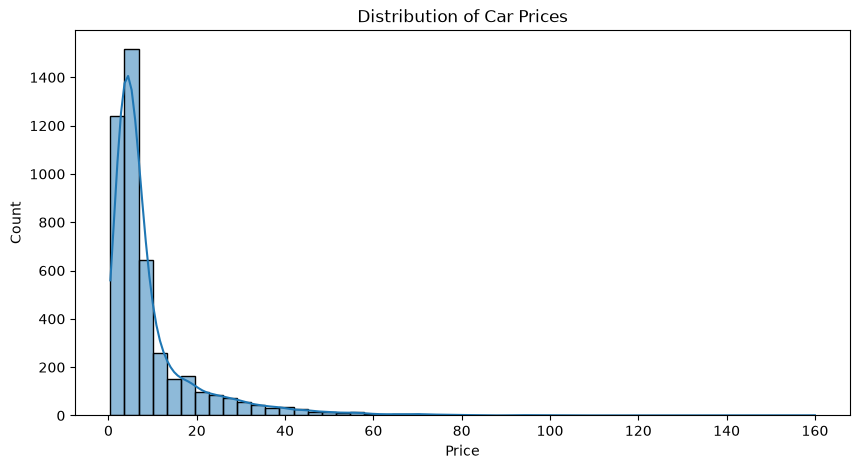

In [64]:
plt.figure(figsize=(10,5))

sns.histplot(
    train['Price'],
    bins=50,
    kde=True
)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

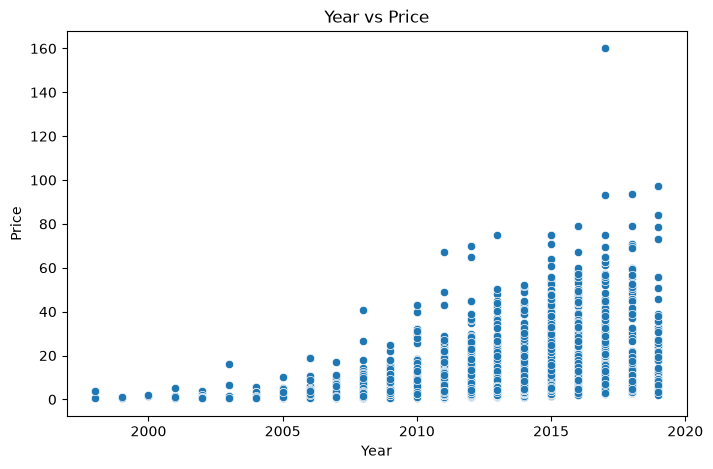

In [65]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=train,
    x="Year",
    y="Price"
)

plt.title("Year vs Price")
plt.show()

In [66]:
train['Name'].value_counts().head(20)

Name
Mahindra XUV500 W8 2WD        37
Maruti Swift VDI              30
Honda City 1.5 S MT           29
Maruti Swift VDI BSIV         26
Maruti Ritz VDi               26
Hyundai i10 Sportz            23
Hyundai Grand i10 Sportz      22
Toyota Fortuner 3.0 Diesel    22
Honda Brio S MT               21
Maruti Swift Dzire VDI        21
Maruti Ertiga VDI             20
Hyundai Verna 1.6 SX          19
Maruti Wagon R VXI            19
Honda City 1.5 V MT           19
Maruti Alto LXi               18
Maruti Ertiga ZDI             18
Maruti Wagon R LXI            18
Honda Amaze S i-Dtech         17
Hyundai EON Era Plus          17
Maruti Swift Dzire VXI        17
Name: count, dtype: int64

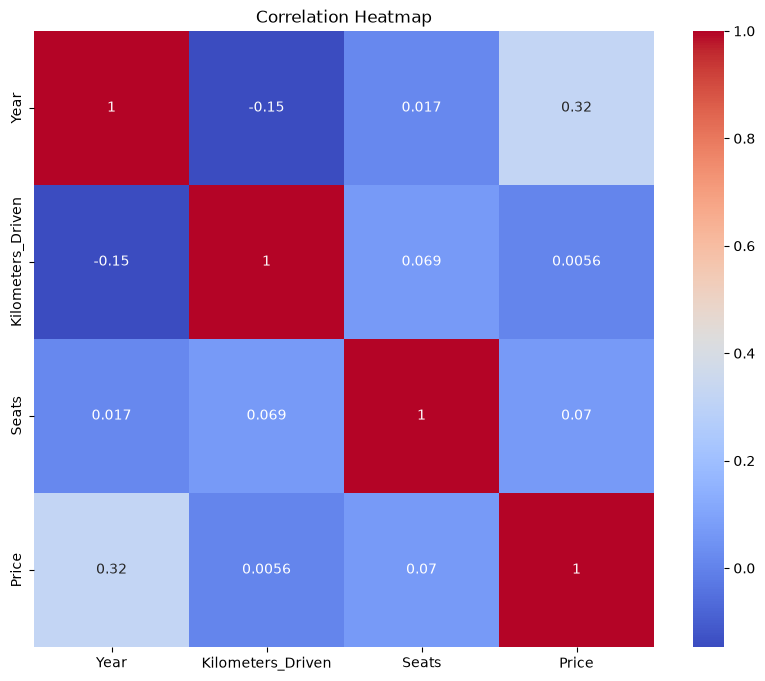

In [67]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">مهندسی ویژگی</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
طبق بررسی‌هایی که از داده‌ها داشته‌اید یا جهت دست‌یابی به عملکرد بهتر در مدل‌های پیش‌بینی‌کننده‌ی خود ممکن است به مهندسی ویژگی‌‌ها (کدگذاری متغیر هدف،‌ حذف ویژگی‌ها، تغییر نوع ویژگی‌ها، ساخت ویژگی جدید، تغییر مقیاس و غیره) نیاز داشته باشید. در این‌صورت می‌توانید در این قسمت از هر روش یا ابزاری که مناسب می‌دانید به‌منظور مهندسی ویژگی‌ها استفاده کنید.
</font>
</p>

# To-Do (Feature Engineering)

## Feature Engineering

Feature engineering is applied to transform the raw dataset into a format that is more suitable for machine learning models.

The following operations are performed:

- Converting Mileage, Engine, and Power features from text format into numerical values.
- Extracting the car brand from the Name feature.
- Removing the original Name feature because it contains many unique values and may increase model complexity.
- Creating a new feature called Car_Age based on the manufacturing year.
- Handling missing numerical values using median imputation.

These transformations help create more meaningful features and improve the predictive performance of the models.

In [68]:
train_fe = train.copy()
test_fe = test.copy()

In [69]:
def convert_mileage(x):
    if pd.isna(x):
        return np.nan
    
    return float(str(x).split()[0])


train_fe['Mileage'] = train_fe['Mileage'].apply(convert_mileage)
test_fe['Mileage'] = test_fe['Mileage'].apply(convert_mileage)

In [70]:
def convert_engine(x):
    if pd.isna(x):
        return np.nan
    
    return float(str(x).split()[0])


train_fe['Engine'] = train_fe['Engine'].apply(convert_engine)
test_fe['Engine'] = test_fe['Engine'].apply(convert_engine)

In [71]:
def convert_power(x):
    if pd.isna(x):
        return np.nan
    
    if x == 'null bhp':
        return np.nan
    
    return float(str(x).split()[0])


train_fe['Power'] = train_fe['Power'].apply(convert_power)
test_fe['Power'] = test_fe['Power'].apply(convert_power)

In [72]:
train_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 4514 entries, 0 to 4513
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               4514 non-null   str    
 1   Location           4514 non-null   str    
 2   Year               4514 non-null   int64  
 3   Kilometers_Driven  4514 non-null   int64  
 4   Fuel_Type          4514 non-null   str    
 5   Transmission       4514 non-null   str    
 6   Owner_Type         4514 non-null   str    
 7   Mileage            4513 non-null   float64
 8   Engine             4486 non-null   float64
 9   Power              4404 non-null   float64
 10  Seats              4481 non-null   float64
 11  Price              4514 non-null   float64
dtypes: float64(5), int64(2), str(5)
memory usage: 423.3 KB


In [73]:
train_fe['Brand'] = train_fe['Name'].apply(lambda x: x.split()[0])
test_fe['Brand'] = test_fe['Name'].apply(lambda x: x.split()[0])

In [74]:
train_fe[['Name','Brand']].head()

,Name,Brand
0,Maruti Wagon R LXI CNG,Maruti
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai
2,Honda Jazz V,Honda
3,Maruti Ertiga VDI,Maruti
4,Audi A4 New 2.0 TDI Multitronic,Audi


In [75]:
train_fe.drop('Name', axis=1, inplace=True)
test_fe.drop('Name', axis=1, inplace=True)

In [76]:
current_year = 2019

train_fe['Car_Age'] = current_year - train_fe['Year']
test_fe['Car_Age'] = current_year - test_fe['Year']

In [77]:
train_fe.head()

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Car_Age
0,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,Maruti,9
1,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,4
2,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Honda,8
3,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti,7
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi,6


In [78]:
train_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 4514 entries, 0 to 4513
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           4514 non-null   str    
 1   Year               4514 non-null   int64  
 2   Kilometers_Driven  4514 non-null   int64  
 3   Fuel_Type          4514 non-null   str    
 4   Transmission       4514 non-null   str    
 5   Owner_Type         4514 non-null   str    
 6   Mileage            4513 non-null   float64
 7   Engine             4486 non-null   float64
 8   Power              4404 non-null   float64
 9   Seats              4481 non-null   float64
 10  Price              4514 non-null   float64
 11  Brand              4514 non-null   str    
 12  Car_Age            4514 non-null   int64  
dtypes: float64(5), int64(3), str(5)
memory usage: 458.6 KB


In [79]:
train_fe.isnull().sum()

Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage                1
Engine                28
Power                110
Seats                 33
Price                  0
Brand                  0
Car_Age                0
dtype: int64

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">مدل‌سازی</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
اکنون می‌توانید با استفاده از الگوریتم‌های یادگیری ماشین، مدلی آموزش دهید که با گرفتن مقادیر ویژگی‌های موجود در دادگان، قیمت خودرو را پیش‌بینی کند.
در این قسمت از شما می‌خواهیم از الگوریتم‌های <b> Regression </b> استفاده کنید و ترکیب‌های مختلفی از هایپرپارامترهای مهم این الگوریتم‌ها را آزمایش کنید تا بهترین مدل را برای پیش‌بینی قیمت خودرو انتخاب کنید. شما می‌توانید برای این منظور،حداقل دو-سه مدل یادگیری ماشینی<b> Regression</b>   را مورد بررسی قرار دهید. در این قسمت می‌توانید از کتابخانه‌ی <code>sklearn</code> استفاده کنید و برای جست‌وجوی هایپرپارامترها می‌توانید از روشی همچون Grid Search استفاده کنید. منطقی است که برای پیدا کردن بهترین ترکیب هایپرپارامتر نیاز به مجموعه‌ی اعتبارسنجی یا استفاده از روش‌هایی مانند Cross Validation دارید.
</font>
</p>

# To-Do (Modeling)

## Modeling

Several regression algorithms are trained and compared to find the best model for used car price prediction.

The evaluated models include:

- Linear Regression as a baseline model.
- Random Forest Regression to capture nonlinear relationships.
- Gradient Boosting Regression to improve predictive performance by combining multiple weak learners.
- Ridge Regression to reduce overfitting using L2 regularization.
- Lasso Regression to perform regularization and feature selection using L1 regularization.

Hyperparameter optimization is performed using GridSearchCV with 5-fold cross-validation to find the best parameter combinations.

In [80]:
X = train_fe.drop('Price', axis=1)
y = train_fe['Price']

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [82]:
print(X_train.shape)
print(X_val.shape)

(3611, 12)
(903, 12)


In [83]:
numeric_features = [
    'Year',
    'Kilometers_Driven',
    'Mileage',
    'Engine',
    'Power',
    'Seats',
    'Car_Age'
]

In [84]:
train_fe.columns

Index(['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
       'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Brand',
       'Car_Age'],
      dtype='str')

In [85]:
categorical_features = [
    'Location',
    'Fuel_Type',
    'Transmission',
    'Owner_Type',
    'Brand'
]

In [86]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)


In [87]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_model.fit(
    X_train,
    y_train
)

lr_train_pred = lr_model.predict(X_train)
lr_val_pred = lr_model.predict(X_val)

lr_train_r2 = r2_score(
    y_train,
    lr_train_pred
)

lr_r2 = r2_score(
    y_val,
    lr_val_pred
)

lr_mae = mean_absolute_error(
    y_val,
    lr_val_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lr_val_pred
    )
)

print("Linear Regression")
print("------------------")
print("Train R2:", lr_train_r2)
print("Validation R2:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

Linear Regression
------------------
Train R2: 0.777968283514109
Validation R2: 0.5976830173611901
MAE: 3.2773849353627194
RMSE: 7.647676288530804


In [88]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ]
)

ridge_model.fit(
    X_train,
    y_train
)

ridge_train_pred = ridge_model.predict(X_train)
ridge_val_pred = ridge_model.predict(X_val)

print("Ridge Regression - Baseline")
print("---------------------------")

print(
    "Train R2:",
    r2_score(y_train, ridge_train_pred)
)

print(
    "Validation R2:",
    r2_score(y_val, ridge_val_pred)
)

print(
    "MAE:",
    mean_absolute_error(y_val, ridge_val_pred)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(y_val, ridge_val_pred)
    )
)

Ridge Regression - Baseline
---------------------------
Train R2: 0.7777002613487582
Validation R2: 0.5937827793262849
MAE: 3.2937315655913784
RMSE: 7.684656849466862


In [89]:
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_ridge.fit(
    X_train,
    y_train
)

print("Best Ridge Parameters:")
print(grid_ridge.best_params_)

print("\nBest Ridge CV R2:")
print(grid_ridge.best_score_)

Best Ridge Parameters:
{'model__alpha': 1}

Best Ridge CV R2:
0.7675037278294379


In [90]:
best_ridge = grid_ridge.best_estimator_

ridge_train_pred = best_ridge.predict(X_train)
ridge_val_pred = best_ridge.predict(X_val)

ridge_train_r2 = r2_score(
    y_train,
    ridge_train_pred
)

ridge_val_r2 = r2_score(
    y_val,
    ridge_val_pred
)

ridge_mae = mean_absolute_error(
    y_val,
    ridge_val_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ridge_val_pred
    )
)

print("\nBest Ridge Regression")
print("---------------------")
print("Train R2:", ridge_train_r2)
print("Validation R2:", ridge_val_r2)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)


Best Ridge Regression
---------------------
Train R2: 0.7777002613487582
Validation R2: 0.5937827793262849
MAE: 3.2937315655913784
RMSE: 7.684656849466862


In [91]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Lasso(max_iter=10000))
    ]
)

param_grid_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10]
}

grid_lasso = GridSearchCV(
    estimator=lasso_model,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_lasso.fit(
    X_train,
    y_train
)

print("Best Lasso Parameters:")
print(grid_lasso.best_params_)

print("\nBest Lasso CV R2:")
print(grid_lasso.best_score_)

Best Lasso Parameters:
{'model__alpha': 0.001}

Best Lasso CV R2:
0.7665788131127925


In [92]:
best_lasso = grid_lasso.best_estimator_

lasso_train_pred = best_lasso.predict(X_train)
lasso_val_pred = best_lasso.predict(X_val)

lasso_train_r2 = r2_score(
    y_train,
    lasso_train_pred
)

lasso_val_r2 = r2_score(
    y_val,
    lasso_val_pred
)

lasso_mae = mean_absolute_error(
    y_val,
    lasso_val_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        lasso_val_pred
    )
)

print("\nBest Lasso Regression")
print("---------------------")
print("Train R2:", lasso_train_r2)
print("Validation R2:", lasso_val_r2)
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)


Best Lasso Regression
---------------------
Train R2: 0.7778707632834629
Validation R2: 0.5966890441377629
MAE: 3.2814509764766617
RMSE: 7.6571177195539555


In [93]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            random_state=42
        ))
    ]
)

rf_model.fit(
    X_train,
    y_train
)

rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)

rf_train_r2 = r2_score(
    y_train,
    rf_train_pred
)

rf_val_r2 = r2_score(
    y_val,
    rf_val_pred
)

rf_mae = mean_absolute_error(
    y_val,
    rf_val_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_val_pred
    )
)

print("Random Forest")
print("----------------")
print("Train R2:", rf_train_r2)
print("Validation R2:", rf_val_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest
----------------
Train R2: 0.9825359923527068
Validation R2: 0.9082042385067199
MAE: 1.5613555555555556
RMSE: 3.653058512452363


In [94]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

gb_model.fit(
    X_train,
    y_train
)

gb_train_pred = gb_model.predict(X_train)
gb_val_pred = gb_model.predict(X_val)

gb_train_r2 = r2_score(
    y_train,
    gb_train_pred
)

gb_val_r2 = r2_score(
    y_val,
    gb_val_pred
)

gb_mae = mean_absolute_error(
    y_val,
    gb_val_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        gb_val_pred
    )
)

print("Gradient Boosting")
print("----------------")
print("Train R2:", gb_train_r2)
print("Validation R2:", gb_val_r2)
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)

Gradient Boosting
----------------
Train R2: 0.9493818607561949
Validation R2: 0.923383306749492
MAE: 1.6844656495216956
RMSE: 3.337390428831956


In [95]:
param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_gb.fit(
    X_train,
    y_train
)

print("Best Gradient Boosting Parameters:")
print(grid_gb.best_params_)

print("\nBest Gradient Boosting CV R2:")
print(grid_gb.best_score_)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

Best Gradient Boosting CV R2:
0.8719526688885499


In [96]:
best_gb = grid_gb.best_estimator_

gb_train_pred = best_gb.predict(X_train)
gb_val_pred = best_gb.predict(X_val)

gb_train_r2 = r2_score(
    y_train,
    gb_train_pred
)

gb_val_r2 = r2_score(
    y_val,
    gb_val_pred
)

gb_mae = mean_absolute_error(
    y_val,
    gb_val_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        gb_val_pred
    )
)

print("Gradient Boosting - Tuned")
print("-------------------------")
print("Train R2:", gb_train_r2)
print("Validation R2:", gb_val_r2)
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)

Gradient Boosting - Tuned
-------------------------
Train R2: 0.9685572008763922
Validation R2: 0.9323253882156143
MAE: 1.5208883765007293
RMSE: 3.1365932292973193


In [97]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Train R2': [
        lr_train_r2,
        ridge_train_r2,
        lasso_train_r2,
        rf_train_r2,
        gb_train_r2
    ],

    'Validation R2': [
        lr_r2,
        ridge_val_r2,
        lasso_val_r2,
        rf_val_r2,
        gb_val_r2
    ],

    'MAE': [
        lr_mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        gb_mae
    ],

    'RMSE': [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results = results.sort_values(
    by='Validation R2',
    ascending=False
)

results

,Model,Train R2,Validation R2,MAE,RMSE
4,Gradient Boosting,0.968557,0.932325,1.520888,3.136593
3,Random Forest,0.982536,0.908204,1.561356,3.653059
0,Linear Regression,0.777968,0.597683,3.277385,7.647676
2,Lasso Regression,0.777871,0.596689,3.281451,7.657118
1,Ridge Regression,0.777700,0.593783,3.293732,7.684657


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
با توجه به نتایجی که بر روی هر ترکیب هایپرپارامتر به دست آورده‌اید،‌ تاثیر هر یک از هایپرپارامترها را بر روی عملکرد مدل چه می‌دانید؟ دلایل و تحلیل خود را در سلول زیر بنویسید:
<span style="color:red">(ضروری)</span>
</font>
</p>

## Hyperparameter Impact Analysis

The hyperparameters affected the performance of the regression models by controlling model complexity and generalization ability.

For Gradient Boosting, GridSearchCV was used to evaluate different hyperparameter combinations. The results showed that selecting appropriate hyperparameters improved the validation performance compared to using default parameters. The hyperparameters control how complex the model becomes and how well it can capture nonlinear relationships in the data. A proper balance is required to achieve good performance without overfitting.

For Ridge and Lasso regression models, the main tuned hyperparameter was `alpha`. This parameter controls the strength of regularization. Smaller values allow the model to fit the training data more closely, while larger values increase regularization and reduce model complexity. The optimal alpha value provides a balance between underfitting and overfitting.

The Random Forest model was evaluated with its default configuration, and it was used as a comparison model to measure the performance of tree-based ensemble methods.

Based on the validation results, Gradient Boosting achieved the highest R² score among the tested models. This indicates that the optimized Gradient Boosting model was able to better capture the complex relationship between vehicle features and price.

<p dir=rtl style="direction: rtl;text-align: center;line-height:200%;font-family:vazir;font-size:medium;color:#0099cc"><font face="vazir" size=3><i>
[تحلیل شما]
</i></font></p>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
حال نتایج مدل نهایی انتخاب‌شده را هم بر روی مجموعه‌ی آموزشی و هم اعتبارسنجی گزارش کنید.
</font>
</p>

# To-Do (Evaluation)

## Model Evaluation

The performance of each regression model is evaluated using several metrics:

- R² Score: The main evaluation metric, representing how well the model explains the variance in car prices.
- Mean Absolute Error (MAE): Measures the average absolute difference between predicted and actual prices.
- Root Mean Squared Error (RMSE): Penalizes larger prediction errors more strongly.

The model with the highest validation R² score is selected as the final model.

In [98]:
final_model = grid_gb.best_estimator_

print("Final Model: Gradient Boosting")
print("Best Parameters:")
print(grid_gb.best_params_)

Final Model: Gradient Boosting
Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}


In [99]:
final_model.fit(
    X,
    y
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Location','Year','Kilometers_Driven',...,'Seats','Brand','Car_Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis

In [100]:
test_predictions = final_model.predict(
    test_fe
)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10])

Number of predictions: 1505
First 10 predictions:
[ 6.03008201  6.41137531  4.37995643 13.10986546  6.24516752  4.604205
  7.5410191   6.8548745   3.41904137 20.00006132]


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">پیش‌بینی برای مجموعه‌ی آزمون</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
اکنون از مدلی که آموزش داده‌اید برای پیش‌بینی نمونه‌های مجموعه‌ی آزمون استفاده کرده تا متوجه شوید که مدل شما تا چه میزان برای نمونه‌های جدید و مشاهده‌نشده موفق عمل می‌کند. نیاز است پیش‌بینی‌های مدل خود را در یک دیتافریم با نام <code>submission</code> که شامل یک ستون به نام <code>Price</code> است ذخیره کنید. ردیف اول از این دیتافریم، پیش‌بینی مدل شما برای نمونه‌ی نخست و ردیف آخر از آن،‌ پیش‌بینی مدل شما برای نمونه‌ی آخر مجموعه‌ی آزمون است. توجه داشته باشید که مقادیر این ستون باید از جنس دسته‌ای و مشابه با مقادیر آن در مجموعه‌ی آموزشی باشد. یک نمونه‌ی فرضی از دیتافریم شما در جدول زیر نشان داده شده است:
</font>
</p>

<center>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>

| <code>Price</code> |
| :---: |
| 6.70 |
| 31.20 |
| 14.58 |
| 10.45 |
| ... |

</font>
</p>
</center>

# TO-DO (Predictions)

## Final Model Selection and Submission

After comparing all evaluated models, Gradient Boosting achieved the highest validation R² score and was selected as the final prediction model.

The selected model was retrained using the complete training dataset and used to predict prices for the unseen test dataset.

The final predictions are stored in a DataFrame named submission with a single column called Price, following the required submission format.

In [101]:
submission = pd.DataFrame({
    'Price': test_predictions
})

print(submission.head())
print("\nSubmission shape:", submission.shape)
print("\nMissing values:")
print(submission.isnull().sum())

       Price
0   6.030082
1   6.411375
2   4.379956
3  13.109865
4   6.245168

Submission shape: (1505, 1)

Missing values:
Price    0
dtype: int64


In [102]:
submission.head()

,Price
0,6.030082
1,6.411375
2,4.379956
3,13.109865
4,6.245168


In [103]:
submission.to_csv(
    'submission.csv',
    index=False
)

print("submission.csv saved successfully.")

submission.csv saved successfully.


<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir">ارزیابی</font>
</h2>


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
معیاری که برای ارزیابی مدل شما استفاده خواهد شد <code>r2-score</code> نام دارد. جهت مطالعه‌ی مستندات این کلاس می‌توانید به <a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html" target="_blank">این لینک</a> مراجعه فرمایید.
</font>
</p>


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
<span style="color:red"><b>توجه:</b></span>
جهت کسب امتیاز کامل نیاز است پاسخ شما حداقل مقدار(درصد) <code>60</code> را با توجه به این معیار کسب کند.
<br>
<span style="color:orange"><b>نکته:</b></span>
برای پاسخ‌هایی که عملکردی کمتر از این حد آستانه کسب کنند، امتیاز <code>0</code> منظور می‌شود و برای عملکردهایی بهتر از این حد آستانه،‌ به همان میزان، نمره‌ی اضافه برای این بخش در نظر گرفته خواهد شد.
<br>
<span style="color:orange"><b>نکته:</b></span>
از ذخیره بودن نت‌بوک خود در ارسال نهایی اطمینان حاصل کنید زیرا که نت‌بوک شما نیز مورد داوری دستی قرار خواهد گرفت و نمره‌ی نهایی شما از ترکیب نمره‌ی پیش‌بینی مدل و نمره‌ی داوری دستی (راه‌حل و تحلیل) محاسبه خواهد شد.
</font>
</p>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>سلول جواب‌ساز</b>
</font>
</h2>

<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
    برای ساخته‌شدن فایل <code>result.zip</code> سلول زیر را اجرا کنید. توجه داشته باشید که پیش از اجرای سلول زیر تغییرات اعمال شده در نت‌بوک را ذخیره کرده باشید (<code>ctrl+s</code>) تا امکان بررسی کد شما وجود داشته باشد.
</font>
</p>

In [104]:
import zipfile
import joblib

def compress(file_names):
    print("File Paths:")
    print(file_names)
    compression = zipfile.ZIP_DEFLATED
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            zf.write('./' + file_name, file_name, compress_type=compression)

submission.to_csv('submission.csv', index=False)
file_names = ['used_cars.ipynb', 'submission.csv']
compress(file_names)

File Paths:
['used_cars.ipynb', 'submission.csv']
